# Imports

In [1]:
import numpy as np
import os

from IPython.testing.ipunittest import count_failures
from more_itertools.recipes import reshape

from mnist.mnist import y_some_digit_pred

%load_ext autoreload
%autoreload 2
import sys
import os


# Get the current folder path and go up one level ('..') to the project root
project_root = os.path.abspath('..')

# Add the root to the system path so Python can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from keras.src.metrics import Precision
from keras.src.metrics.metrics_utils import confusion_matrix

np.random.seed(42) #to make results reproducible

# Matplotlib and seaborn configuration
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Function to Save figures


In [2]:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "Classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id , tight_layout =True, fig_extension = "png", resolution=300):
    path = os.path.join(IMAGES_PATH , fig_id + "." + fig_extension )
    print("Saving figure", fig_id )
    if tight_layout:
        plt.tight_layout()
        plt.savefig(path, format = fig_extension,dpi=resolution)

# Importing Dataset

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1 , as_frame= False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
print(mnist["frame"])
print(mnist["feature_names"])
print(mnist["target_names"])

None
['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91', 'p

In [5]:
print(mnist["categories"])

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}


In [6]:
print("description" , mnist["DESCR"])
print("details", mnist["details"])
print("categories", mnist["categories"])
print("url", mnist["url"])

description **Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 2

In [7]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


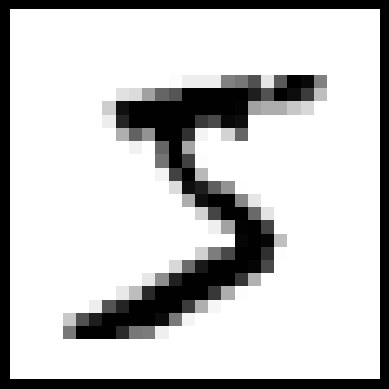

Saving figure some_digit_plot


<Figure size 640x480 with 0 Axes>

In [8]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()
save_fig("some_digit_plot")

In [9]:
y[0]

'5'

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 5 Detector


In [11]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

In [12]:
#lets pick a classifier now and train ,1st we go with stochastic Gradient Descent Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [13]:
sgd_clf.predict(some_digit.reshape(1, -1))

array([ True])

# Performance Measures

In [14]:
# cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [15]:
# is it correct?
#dummy classifier for no 5 elements

from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [16]:
#this model accuracy
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.90965, 0.90965, 0.90965])

it has over 90 percent accuracy for the no. is not 5 , only because 10 percent images are 5s , so most of the time is not 5 , here we can see that its not a good idea to use the accuracy as a good parameter to judge the classifier performance, especially for the skewed datasets. Here we use *Confusion Matrix (CM)*

In [17]:
# for more control on cross validation we can use StratifiedKfold

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) #if dataset not shuffled already also add shuffle = True

for train_index , test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train[test_index]

    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct/len(y_pred))


0.0
0.0
0.0


In [18]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm
#Each row in a confusion matrix represents an actual class, while each column represents a predicted class.
#first row here shows the non-5s while the 687 here are 5s but false positive, false positives also known as type I errors,
#in 2nd row 1891 were wrongly classified as non 5s ,  False negatives are known as type II errors, while 3530 true Positives

array([[53892,   687],
       [ 1891,  3530]])

In [20]:
y_train_perfect_predictions = y_train_5 # pretend for reaching perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

since CM give u a lot of info about the data but , sometime its better to use Concise metric for positive predictions , this is known as precision of the classifier.

# Precision and Recall
it is better to combine them both to F1 score (mean of precision and recall)

In [24]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)


0.8370879772350012

In [23]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [25]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)
# increasing precision reduces
#recall, and vice versa. This is called the precision/recall trade-off.

0.7325171197343847

# Precision/Recall Trade-off
 to understand this we need to understand how SGD classifier makes its classification decisions , for each instance it uses its decision functn to compute the score. if the score is greater than the threshold it assign it to the positive class otherwise negative class.

sciket doesnt allow us to set the threshold directly but it does give u the access to decision scores , that is used for making predictions

In [26]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [27]:
threshold = 0

In [29]:
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [30]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

This confirms that raising the threshold decreases recall. The image actually
represents a 5, and the classifier detects it when the threshold is 0, but it
misses it when the threshold is increased to 3,000.
now how to decide which threshold to use ?

 First, use the
cross_val_predict() function to get the scores of all instances in the
training set, but this time specify that you want to return decision scores
instead of predictions:



In [31]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [32]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

Saving figure precision_recall_vs_threshold_plot


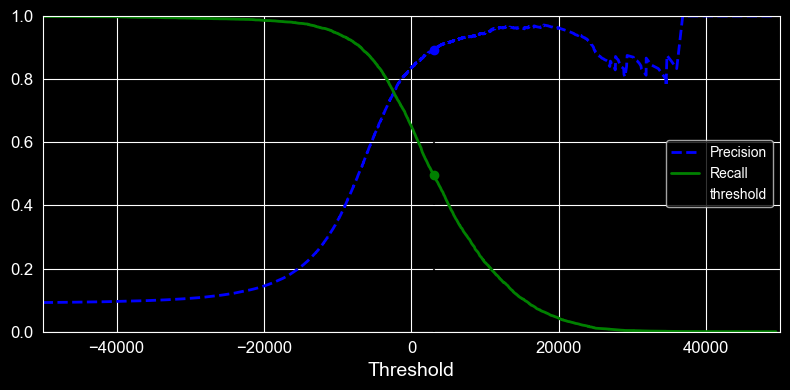

In [35]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

Saving figure precision_vs_recall_plot


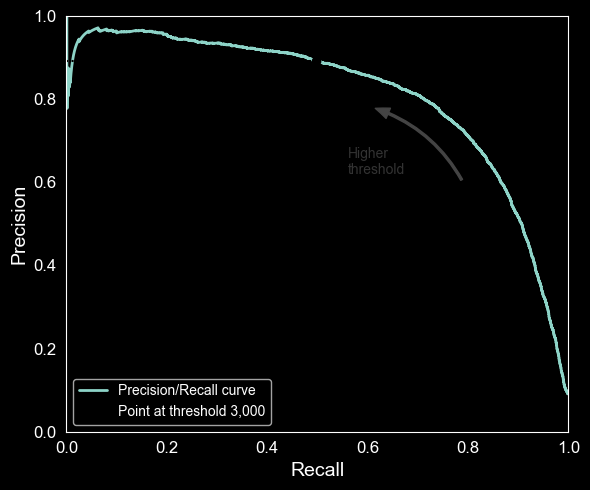

In [36]:
# another way to select a good precision/recall trade off is to plot precision directly against recall

import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()